# 2.7 

The file `w_logret_3automanu.txt` contains the weekly log returns of three auto manufacturers, General Motors Corp., Ford Motor Corp., and Toyota Motor Corp., from the week of January 3, 1994 to the week of June 25, 2007.

(a) Write down the sample covariance matrix $\hat{V}$ of these returns.

Import necessary libraries

In [10]:
import pandas as pd
import numpy as np
from itertools import combinations

from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import f, t

import seaborn as sns
from scipy import stats

from scipy.optimize import minimize

plt.rcParams['text.usetex'] = True

In [7]:
# Load dataset
auto_returns = pd.read_csv('w_logret_3automanu.csv', 
                          usecols=[1, 2, 3], header=0)

In [8]:
# Compute sample covariance matrix
S = auto_returns.cov()
print("Sample covariance matrix S:")
print(S)

Sample covariance matrix S:
          Toyota      Ford        GM
Toyota  0.000259  0.000076  0.000063
Ford    0.000076  0.000378  0.000237
GM      0.000063  0.000237  0.000396


(b) For each pair of these three automotive companies, construct a 95% confidence interval for their return correlation coefficients


From Exercise 2.6(b), we have the asymptotic distribution:

$$\begin{equation*}
\sqrt{n}(\hat{\rho} - \rho) \stackrel{d}{\to} N\left(0, (1-\rho^2)^2\right)
\end{equation*}$$

For large $n$:

$$\begin{equation*}
\hat{\rho} \approx N\left(\rho, \frac{(1-\rho^2)^2}{n}\right)
\end{equation*}$$

Using the Fisher z-transformation to ensure confidence intervals remain within $[-1, 1]$:
$$
\begin{align*}
\hat{z} &= \mathrm{arctanh}(\hat{\rho}) \
\zeta &= \mathrm{arctanh}(\rho)
\end{align*}
$$

The asymptotic distribution becomes:
$$
\begin{equation*}
\hat{z} \approx N\left(\zeta, \frac{1}{n}\right)
\end{equation*}$$

The 95% confidence interval for $\zeta$:
$$
\begin{equation*}
\hat{z} \pm 1.96 \cdot \frac{1}{\sqrt{n}}
\end{equation*}
$$

Transforming back to the correlation scale:
$$
\begin{align*}
\rho_{\text{lower}} &= \tanh\left(\hat{z} - \frac{1.96}{\sqrt{n}}\right) \
\rho_{\text{upper}} &= \tanh\left(\hat{z} + \frac{1.96}{\sqrt{n}}\right)
\end{align*}
$$

In [11]:
sample_size = len(auto_returns)
stock_combinations = list(combinations(auto_returns.columns, 2))

for company1, company2 in stock_combinations:
    corr_coef = auto_returns[company1].corr(auto_returns[company2])
    
    # Fisher z-transformation
    fisher_z = np.arctanh(corr_coef)
    fisher_z_se = 1 / np.sqrt(sample_size)
    
    # 95% CI for z
    fisher_z_lower = fisher_z - 1.96 * fisher_z_se
    fisher_z_upper = fisher_z + 1.96 * fisher_z_se
    
    # Transform back to correlation scale
    corr_lower = np.tanh(fisher_z_lower)
    corr_upper = np.tanh(fisher_z_upper)
    
    print(f"{company1} vs {company2}:")
    print(f"  Sample correlation coefficient = {corr_coef:.4f}")
    print(f"  95% confidence interval = ({corr_lower:.4f}, {corr_upper:.4f})")
    print()

Toyota vs Ford:
  Sample correlation coefficient = 0.2425
  95% confidence interval = (0.1720, 0.3104)

Toyota vs GM:
  Sample correlation coefficient = 0.1952
  95% confidence interval = (0.1235, 0.2649)

Ford vs GM:
  Sample correlation coefficient = 0.6125
  95% confidence interval = (0.5644, 0.6564)



(c) Assumptions and Graphical Validation

The statistical inference in part (b) relies on:

* Reasonable approximation of bivariate normality
* Independent and identically distributed observations
* Sufficiently large sample size for asymptotic approximations

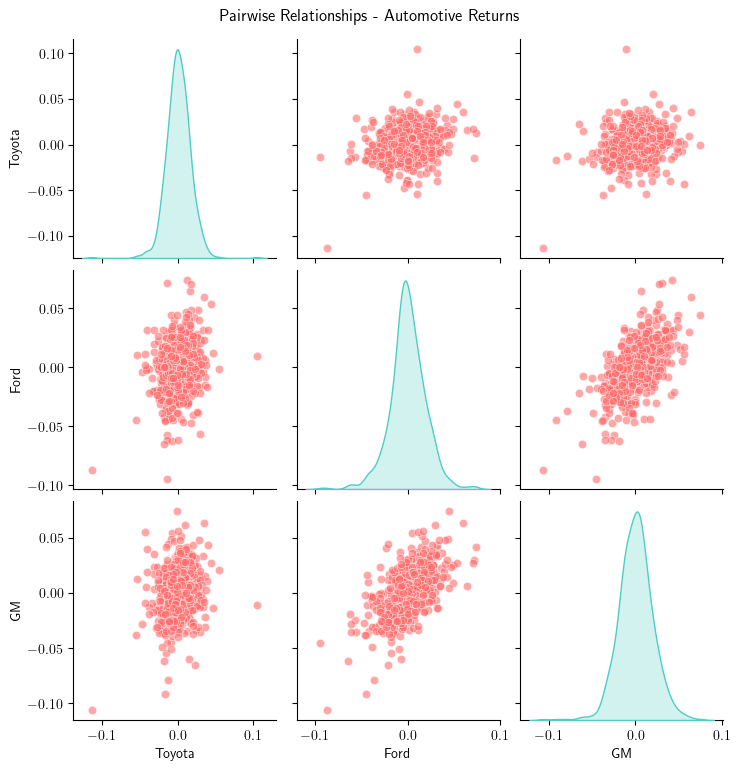

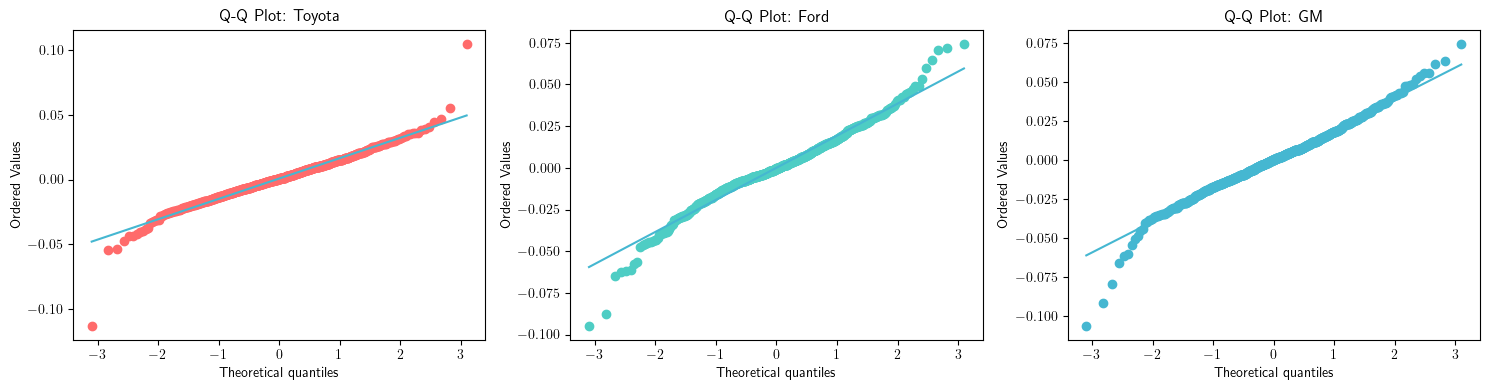

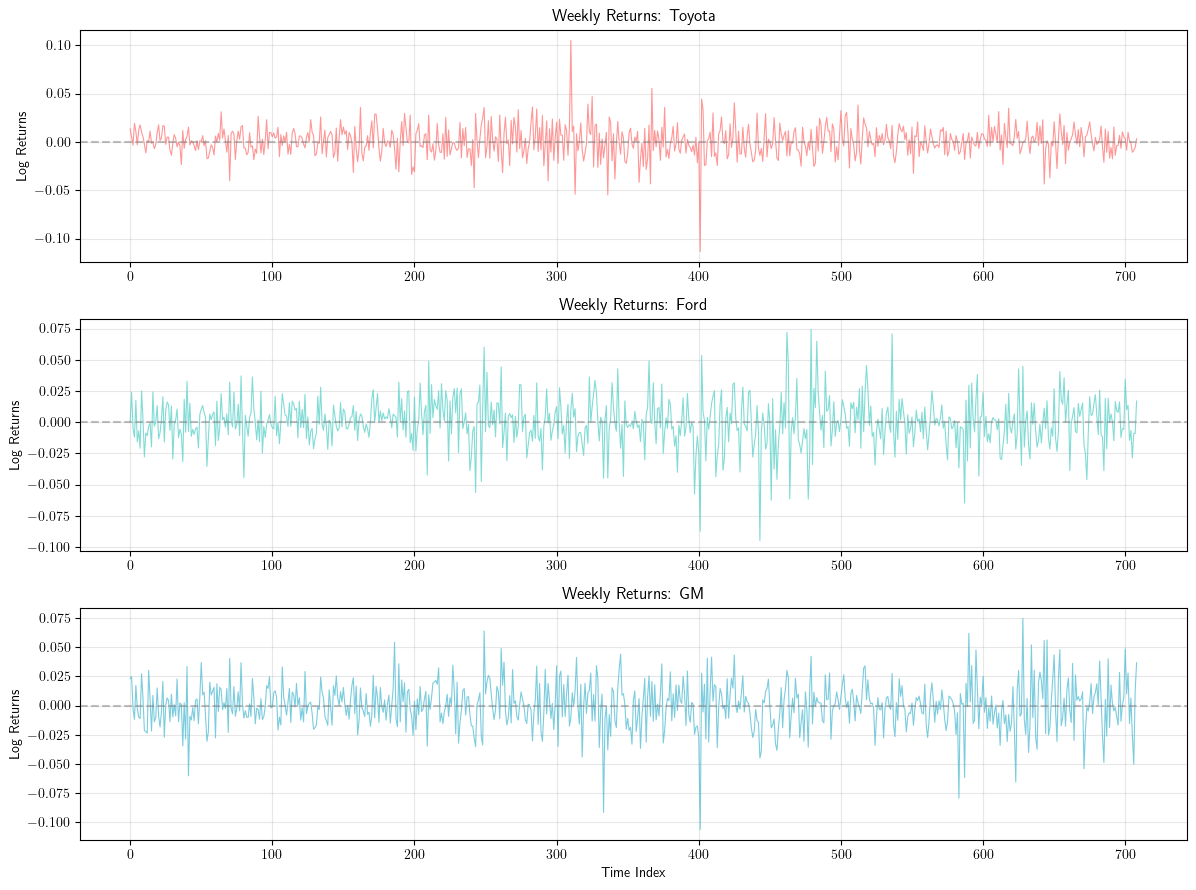

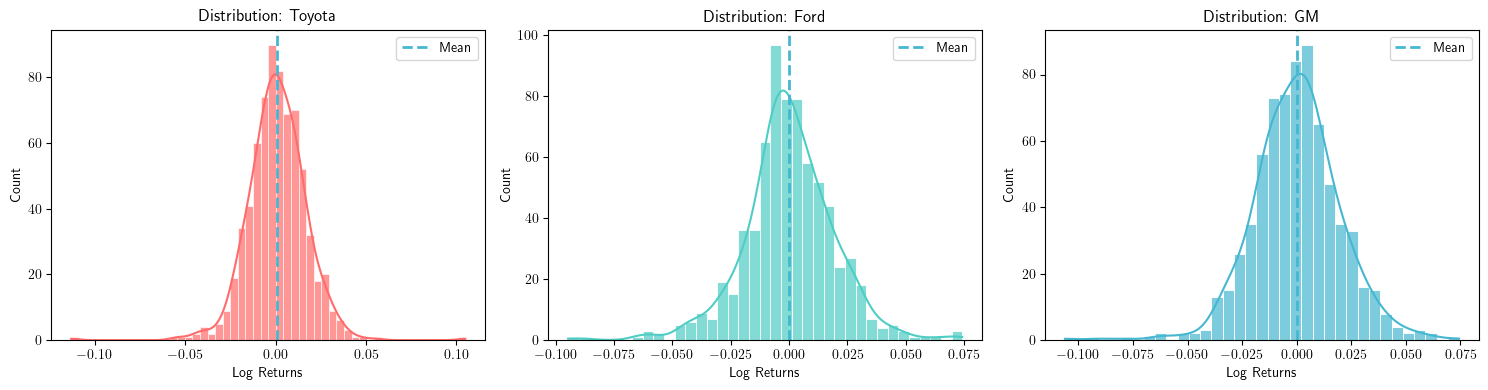

In [12]:
# Color scheme
plt_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Coral, Turquoise, Sky Blue

# Create pairwise scatter plots
pair_grid = sns.pairplot(auto_returns, diag_kind='kde', 
                         plot_kws={'alpha': 0.6, 'color': plt_colors[0]},
                         diag_kws={'color': plt_colors[1]})
pair_grid.fig.suptitle('Pairwise Relationships - Automotive Returns', y=1.02)
plt.show()

# Generate Q-Q plots for each company
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    stats.probplot(auto_returns[company].dropna(), dist="norm", plot=axes[idx])
    axes[idx].get_lines()[0].set_markerfacecolor(color)
    axes[idx].get_lines()[0].set_markeredgecolor(color)
    axes[idx].get_lines()[1].set_color(plt_colors[2])  # Different color for reference line
    axes[idx].set_title(f'Q-Q Plot: {company}')
    axes[idx].set_ylabel('Ordered Values')

plt.tight_layout()
plt.show()

# Time series visualization
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    axes[idx].plot(auto_returns.index, auto_returns[company], 
                   color=color, alpha=0.7, linewidth=0.8)
    axes[idx].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].set_ylabel('Log Returns')
    axes[idx].set_title(f'Weekly Returns: {company}')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Time Index')
plt.tight_layout()
plt.show()

# Distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (company, color) in enumerate(zip(auto_returns.columns, plt_colors)):
    sns.histplot(auto_returns[company], kde=True, ax=axes[idx], 
                 color=color, edgecolor='white', alpha=0.7)
    axes[idx].axvline(x=auto_returns[company].mean(), color=plt_colors[2], 
                      linestyle='--', linewidth=2, label='Mean')
    axes[idx].set_title(f'Distribution: {company}')
    axes[idx].set_xlabel('Log Returns')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 3.4 

Let $\widehat{\boldsymbol{\mu}}$ and $\widehat{\boldsymbol{\Sigma}}$ denote the sample mean and the sample covariance matrix of the observed sample $\{{\bf r}_{1},\ldots,{\bf r}_{n}\}$, and let $\widehat{\mathbf{w}}_{b}^{*}$ be the estimated optimal portfolio weight vector based on the $b$-th bootstrap sample $\{{\bf r}_{b1}^{*},\ldots,{\bf r}_{bn}^{*}\}$ drawn with replacement from the observed sample $\{{\bf r}_{1},\ldots,{\bf r}_{n}\}$. The file `d_logret_6stocks.txt` contains the log returns of six stocks in  Section 3.2.4.

(a) Use one bootstrap sample to plot the curve $\left( \sqrt{(\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\Sigma}} \,\widehat{\mathbf{w}}_b^*}, \; (\widehat{\mathbf{w}}_b^*)^{\!\top} \widehat{\boldsymbol{\mu}} \right)$ for different target mean returns $\mu_*$.

In [13]:
sample_mean_vector = auto_returns.mean()
print("Sample Mean Vector μ̂:")
print(sample_mean_vector)
print("\n" + "="*60 + "\n")

print("Sample Covariance Matrix S:")
print(S)
print("\n" + "="*60 + "\n")

Sample Mean Vector μ̂:
Toyota    0.000869
Ford      0.000075
GM        0.000170
dtype: float64


Sample Covariance Matrix S:
          Toyota      Ford        GM
Toyota  0.000259  0.000076  0.000063
Ford    0.000076  0.000378  0.000237
GM      0.000063  0.000237  0.000396




# 4.7 

In [ ]:
# Data Loading and Processing
def load_and_process_data():
    # Load Market Data (S&P 500 and 3-month T-bill)
    # File has columns: Date, SP500, 3mTCM
    #mkt_df = pd.read_csv('m_sp500ret_3mtcm.txt', sep=r'\s+', header=None, skiprows=1)
    mkt_df = pd.read_csv('/Users/winnie/Desktop/m_sp500ret_3mtcm.txt', sep=r'\s+', header=None, skiprows=1)
    mkt_df.columns = ['Date', 'SP500_Ret', '3mTCM']
    mkt_df['Date'] = pd.to_datetime(mkt_df['Date'], format='%b-%y')
    mkt_df.set_index('Date', inplace=True)
    
    # Convert annualized T-bill % to monthly decimal risk-free rate (for convenience we treat it as a simple nominal rate)
    mkt_df['rf'] = (mkt_df['3mTCM'] / 100) / 12

    # Load Stock Data (Log returns)
    # File has columns: Date, AAPL, ADBE, ...
    #stk_df = pd.read_csv('m_logret_10stocks.txt', sep=r'\s+')
    stk_df = pd.read_csv('/Users/winnie/Desktop/m_logret_10stocks.txt', sep=r'\s+')
    stk_df['Date'] = pd.to_datetime(stk_df['Date'])
    stk_df.set_index('Date', inplace=True)
    
    # Convert Log Returns to Simple Returns: R = exp(r) - 1
    stk_simple_ret = np.exp(stk_df) - 1
    
    # Align data (intersection of dates)
    common_dates = mkt_df.index.intersection(stk_simple_ret.index)
    stk_simple_ret = stk_simple_ret.loc[common_dates]
    mkt_df = mkt_df.loc[common_dates]
    
    return stk_simple_ret, mkt_df


a) Using a single-index model (see Exercise 3.3) for the structured covariance matrix $F$, calculate the estimate $\hat{F}$ of $F$ in (4.45).

In [3]:
# Covariance Estimation Methods
def single_index_covariance(stk_returns, mkt_returns):
    """
    Estimates F using Single Index Model: F = beta * beta' * var_m + D
    """
    # X = Market Excess Returns (constant added for intercept)
    X = np.vstack([np.ones(len(mkt_returns)), mkt_returns]).T
    Y = stk_returns.values
    
    # Beta estimation: (X'X)^-1 X'Y
    # Here X has 2 columns (alpha, beta). We want the 2nd coef (beta).
    betas = []
    resid_vars = []
    
    for i in range(Y.shape[1]):
        y_col = Y[:, i]
        coeffs = np.linalg.lstsq(X, y_col, rcond=None)[0]
        beta = coeffs[1]
        
        # Residuals
        y_pred = X @ coeffs
        residuals = y_col - y_pred
        # Residual variance (MLE, divisor T)
        resid_var = np.mean(residuals**2)
        
        betas.append(beta)
        resid_vars.append(resid_var)
        
    betas = np.array(betas).reshape(-1, 1)
    D = np.diag(resid_vars)
    var_m = np.var(mkt_returns, ddof=0) # MLE variance
    
    F_sim = var_m * (betas @ betas.T) + D
    return F_sim

(b)

In [2]:
# Ledoit-Wolf Shrinkage Logic
class LedoitWolfShrinkage:
    def __init__(self, returns):
        """
        returns: DataFrame of asset returns (T x N)
        """
        self.R = returns.values
        self.T, self.N = self.R.shape
        self.means = np.mean(self.R, axis=0)
        
        # Centered returns (y_it)
        self.Y = self.R - self.means
        
        # Sample Covariance Matrix S (using divisor n, consistent with text formulas)
        self.S = (self.Y.T @ self.Y) / self.T
        
        # Pre-compute Pi_hat and Rho_hat components that depend only on Data (S)
        self.pi_hat, self.pi_diag = self._compute_pi_hat()
        self.rho_hat = self._compute_rho_hat()

    def _compute_pi_hat(self):
        # pi_hat_ij = 1/T * sum_t [ (y_it*y_jt - s_ij)^2 ]
        # We can compute this efficiently using numpy broadcasting
        pi_mat = np.zeros((self.N, self.N))
        
        # Loop is clearer for exact implementation of the formula
        for i in range(self.N):
            for j in range(self.N):
                term = (self.Y[:, i] * self.Y[:, j]) - self.S[i, j]
                pi_mat[i, j] = np.mean(term**2) # mean implies 1/T sum
                
        return np.sum(pi_mat), np.diag(pi_mat)

    def _compute_rho_hat(self):
        # 1. Calculate average correlation r_bar
        # r_bar = 2 / (p(p-1)) * sum_{i<j} s_ij / sqrt(s_ii * s_jj)
        correlations = []
        std_devs = np.sqrt(np.diag(self.S))
        
        for i in range(self.N):
            for j in range(i + 1, self.N):
                corr = self.S[i, j] / (std_devs[i] * std_devs[j])
                correlations.append(corr)
        r_bar = np.mean(correlations)
        
        # Calculate Theta terms and Rho
        # rho_hat = sum(pi_ii) + sum_{i} sum_{j!=i} r_bar/2 * (sqrt(s_jj/s_ii)*theta_i,ij + ...)
        
        # Need theta_k_ij. We only need cases where k=i and k=j
        # theta_i,ij = 1/T * sum_t [ (y_it^2 - s_ii)(y_it*y_jt - s_ij) ]
        
        rho_sum_off_diag = 0.0
        
        for i in range(self.N):
            for j in range(self.N):
                if i == j: continue
                
                # Calculate theta_i_ij
                term_i = (self.Y[:, i]**2) - self.S[i, i]
                term_ij = (self.Y[:, i] * self.Y[:, j]) - self.S[i, j]
                theta_i_ij = np.mean(term_i * term_ij)
                
                # Calculate theta_j_ij
                term_j = (self.Y[:, j]**2) - self.S[j, j]
                theta_j_ij = np.mean(term_j * term_ij)
                
                # Term for rho
                sqrt_rat_1 = np.sqrt(self.S[j, j] / self.S[i, i])
                sqrt_rat_2 = np.sqrt(self.S[i, i] / self.S[j, j])
                
                bracket = sqrt_rat_1 * theta_i_ij + sqrt_rat_2 * theta_j_ij
                rho_sum_off_diag += (r_bar / 2.0) * bracket
                
        rho_val = np.sum(self.pi_diag) + rho_sum_off_diag
        return rho_val

    def shrink(self, F_target):
        """
        Calculates shrinkage intensity delta and final matrix using target F.
        """
        # Calculate Gamma Hat
        # gamma = sum_ij (f_ij - s_ij)^2
        gamma_hat = np.sum((F_target - self.S)**2)
        
        # Calculate Delta
        # kappa = (pi - rho) / gamma
        kappa = (self.pi_hat - self.rho_hat) / gamma_hat
        
        # delta = max(0, min(1, kappa/T))
        delta = max(0, min(1, kappa / self.T))
        
        # Final Estimator
        Sigma_hat = delta * F_target + (1 - delta) * self.S
        
        return Sigma_hat, delta

(c) Perform PCA on the ten stocks. Using the first two principal components as factors in a two-factor model for $F$ (see Section 3.4.3), estimate $F$

In [ ]:
def pca_covariance(stk_returns, n_components=2):
    """
    Estimates F using PCA Factor Model (k=2).
    Standardize -> PCA -> Reconstruct Covariance
    """
    # Correlation matrix
    corr_mat = stk_returns.corr()
    std_devs = stk_returns.std(ddof=0) # MLE std for consistency
    
    # PCA on Correlation
    pca = PCA(n_components=n_components)
    pca.fit(corr_mat)
    
    # Get loadings (L) = eigenvectors * sqrt(eigenvalues)
    # In sklearn: components_ are eigenvectors * sqrt(evals)
    # explained_variance_ are eigenvalues.
    L = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    # Reconstruct Correlation: R_hat = L * L.T + Psi
    # Psi is diagonal of (Real Corr - L*L.T)
    R_common = L @ L.T
    R_resid = np.diag(np.diag(corr_mat - R_common))
    R_hat = R_common + R_resid
    
    # Convert back to Covariance: Sigma_hat = D * R_hat * D
    D_std = np.diag(std_devs)
    F_pca = D_std @ R_hat @ D_std
    
    return F_pca

(d) Using the estimated $\hat{F}$ in (c) as the shrinkage target in (4.45), compute the new value of $\hat{\delta}$ and the new shrinkage estimate (4.45) of $\Sigma$. Plot the corresponding estimated efficient frontier and compare it with that in (b).

In [6]:
# Efficient Frontier Plotting
def calculate_frontier(mu, Sigma, num_points=100):
    """
    Calculates (std, ret) points for efficient frontier (with short selling).
    """
    ones = np.ones(len(mu))
    Sigma_inv = np.linalg.inv(Sigma)
    
    A = ones.T @ Sigma_inv @ ones
    B = ones.T @ Sigma_inv @ mu
    C = mu.T @ Sigma_inv @ mu
    delta = A*C - B**2
    
    # Range of returns
    mu_min = np.min(mu)
    mu_max = np.max(mu)
    target_mus = np.linspace(mu_min * 0.9, mu_max * 1.2, num_points)
    
    target_vars = (A * target_mus**2 - 2*B * target_mus + C) / delta
    target_stds = np.sqrt(target_vars)
    
    return target_stds, target_mus

## Results (main execution)

Part (a): F_SIM computed.
Part (b): Optimal Shrinkage Intensity (SIM): 0.328881
Part (c): F_PCA computed.
Part (d): Optimal Shrinkage Intensity (PCA): 0.074511


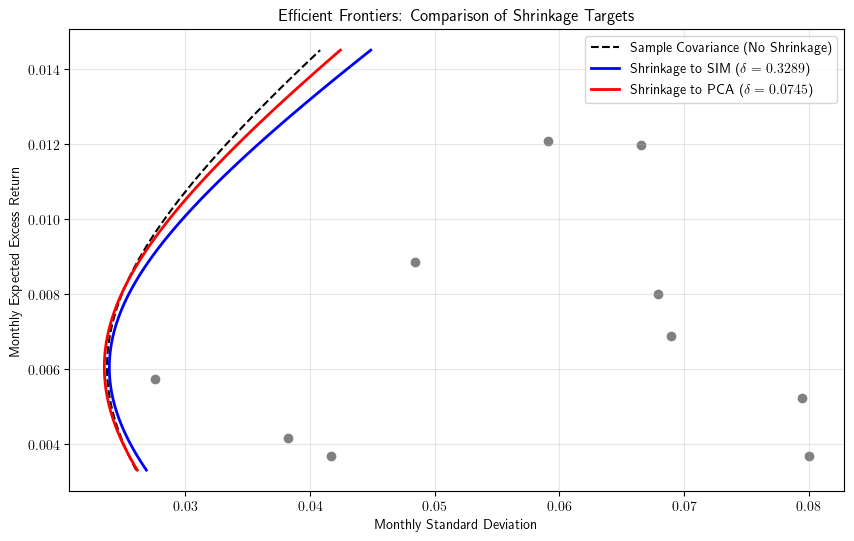

In [12]:
# Main Execution

# Load Data
stk_ret, mkt_df = load_and_process_data()

# Excess Returns
stk_excess = stk_ret.sub(mkt_df['rf'], axis=0)
mkt_excess = mkt_df['SP500_Ret'] - mkt_df['rf']

# Part (a): Single Index Model F
F_sim = single_index_covariance(stk_excess, mkt_excess)
print("Part (a): F_SIM computed.")

# Part (b): Shrinkage with F_SIM 
lw = LedoitWolfShrinkage(stk_excess)
Sigma_sim, delta_sim = lw.shrink(F_sim)

print(f"Part (b): Optimal Shrinkage Intensity (SIM): {delta_sim:.6f}")

# Part (c): PCA Factor Model F
# Using raw stock returns for correlation structure (standard practice) or excess?
# Covariance of excess returns is same as covariance of raw returns (rf is constant per month)
F_pca = pca_covariance(stk_excess, n_components=2)
print("Part (c): F_PCA computed.")

# Part (d): Shrinkage with F_PCA
Sigma_pca, delta_pca = lw.shrink(F_pca)
print(f"Part (d): Optimal Shrinkage Intensity (PCA): {delta_pca:.6f}")

# Plotting 
mu = stk_excess.mean().values

std_sim, mu_sim = calculate_frontier(mu, Sigma_sim)
std_pca, mu_pca = calculate_frontier(mu, Sigma_pca)
std_sample, mu_sample = calculate_frontier(mu, lw.S) # For reference

plt.figure(figsize=(10, 6))
plt.plot(std_sample, mu_sample, 'k--', label='Sample Covariance (No Shrinkage)')
plt.plot(std_sim, mu_sim, 'b-', linewidth=2, label=rf'Shrinkage to SIM ($\delta={delta_sim:.4f}$)')
plt.plot(std_pca, mu_pca, 'r-', linewidth=2, label=rf'Shrinkage to PCA ($\delta={delta_pca:.4f}$)')

# Plot individual assets
stk_stds = np.sqrt(np.diag(lw.S))
plt.scatter(stk_stds, mu, c='gray', marker='o')

plt.title('Efficient Frontiers: Comparison of Shrinkage Targets')
plt.xlabel('Monthly Standard Deviation')
plt.ylabel('Monthly Expected Excess Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()